# S1–S3 流程

本 Notebook 演示 S1 读取数据、S2 可视化/高通滤波、S3 候选 spike 检测。

In [1]:
%matplotlib widget

import sys
sys.path.append(r"d:\Desktop\Spike sort")


from Main.S1 import load_input
from Main.S2 import plot_raw, highpass_filter, plot_hp
from Main.S3 import pick_threshold, detect_candidates,plot_waveform_overlay
import os
import numpy as np


In [ ]:
data_dir = "../Data/Spike data/c57_v_c57_test1.mat"
raw_input = load_input(data_dir, data_type="raw")
raw = raw_input.raw
raw.shape


(16, 1, 25656682)

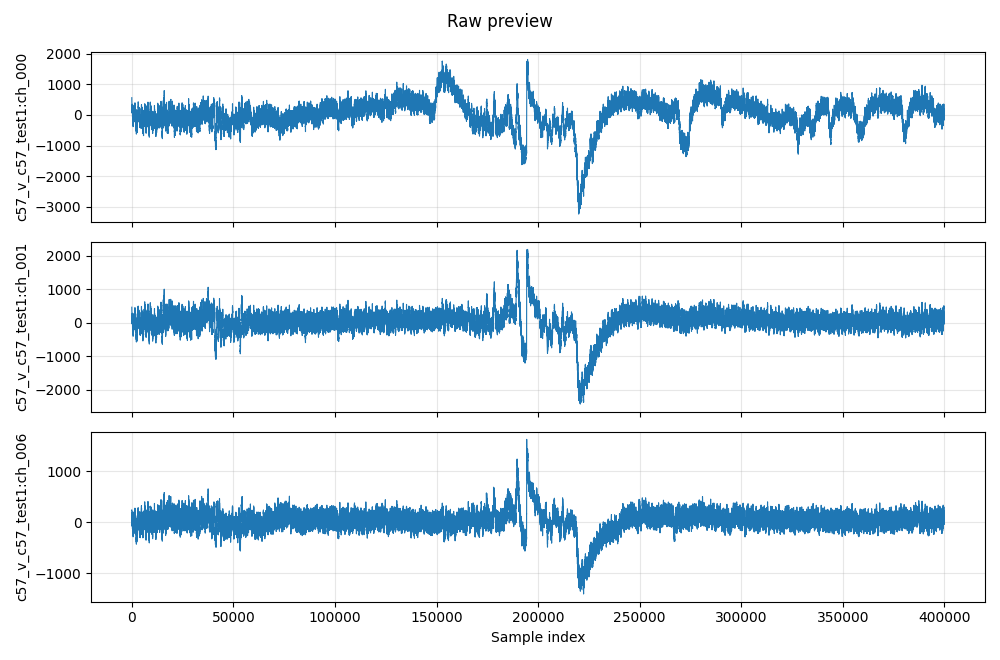

In [3]:
# 选择部分通道可视化
plot_raw(raw, channels=[0, 1, 6], start=0, stop=400000, title="Raw preview")

In [4]:
# 高通滤波
#采样频率
fs_hz = 40000
hp = highpass_filter(raw, fs_hz=fs_hz, cutoff_hz=200.0)
hp.data.shape

(16, 1, 25656682)

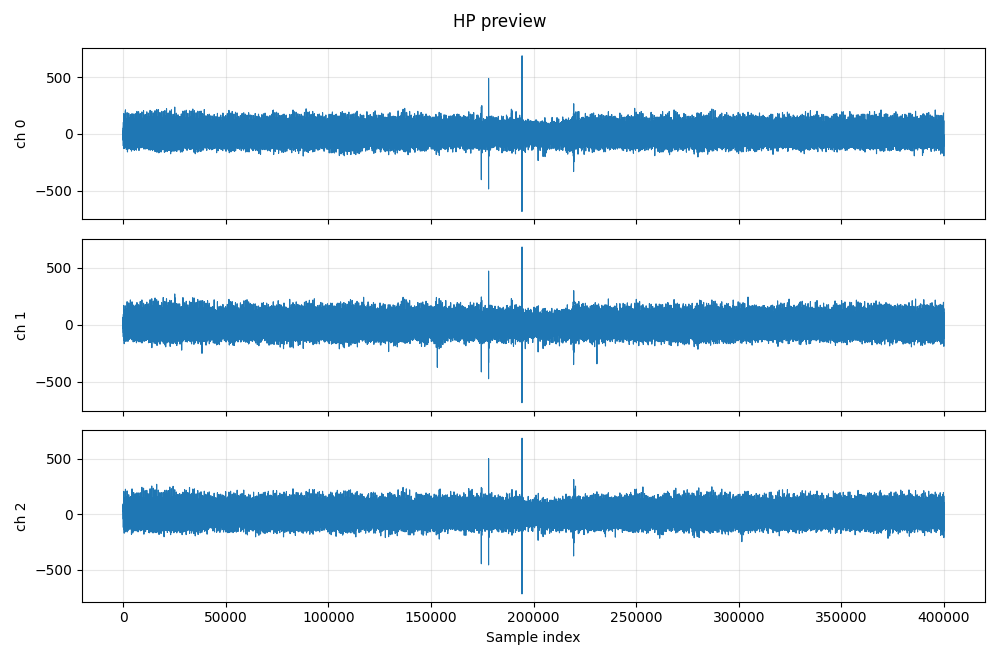

In [5]:
plot_hp(hp, channels=[0, 1, 2], start=0, stop=400000, title="HP preview")

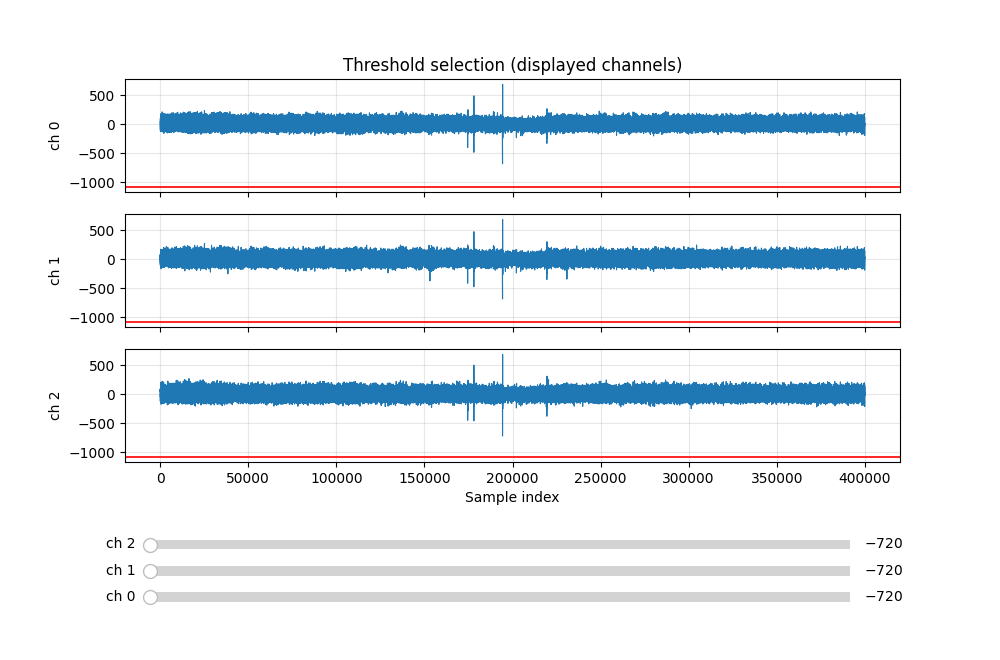

In [6]:
# 交互设置阈值

thresholds = pick_threshold(hp.data, channels=[0,1,2], start=0, stop=400000)


In [7]:

thresholds = [-167, -167, -167, -167, -167, -167, -167, -167,
              -167, -167, -167, -167, -167, -167, -167, -167]

# thresholds= -191

In [10]:
# 候选检测
cands = detect_candidates(hp.data, threshold=thresholds, pre=20, post=31)
cands.X.shape, cands.T0.shape

((16, 89686, 52), (16, 89686))

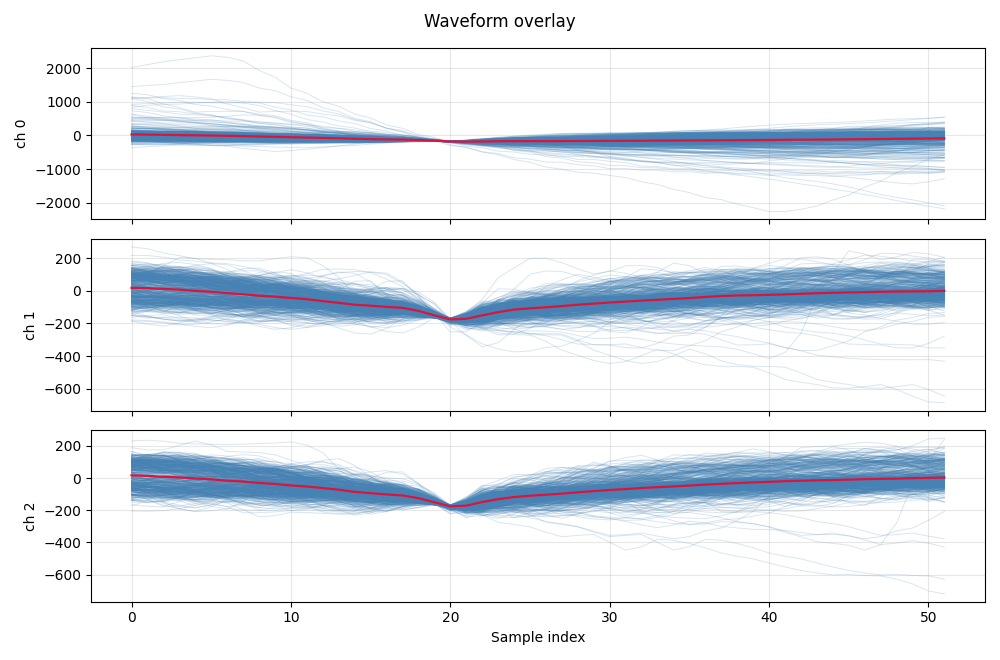

In [13]:
plot_waveform_overlay(cands.X, channels=[0 , 1 , 2], max_waveforms=500, title="Waveform overlay")

In [16]:
import os
import numpy as np

out_dir = "../Data/Process data"
os.makedirs(out_dir, exist_ok=True)


np.savez(
    os.path.join(out_dir, "c57_v_c57_test1_wave_events.npz"),
    X=cands.X,             # C x N x t
    T0=cands.T0,           # C x N
    channel_names=np.array(raw.channel_names, dtype=object),
)